In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from calibration import load_data, separate_ch_sig, rectify, bandpass_filter, lowpass_filter


calibration before stim analysis

In [2]:
dir = r"C:\Users\User\Desktop\Maryam_Test_Files\MTS_Test\2025 - 10 - 16"
_calib = r"\calibration\MTS_Test_RawFormattedEMGData_2025 - 10 - 16_15 - 58 - 23.csv"
_filt_calib = r"\calibration\MTS_Test_FiltEMGData_2025 - 10 - 16_15 - 58 - 23.csv"
_env_calib = r"\calibration\MTS_Test_EnvData_2025 - 10 - 16_15 - 58 - 23.csv"

In [ ]:
_calib = r"\calibration\trial1\MTS_Test_RawFormattedEMGData_2025 - 10 - 16_15 - 46 - 33.csv"
calib = pd.read_csv(dir+_calib)
plt.plot(calib.EMG1)

In [3]:
calib = pd.read_csv(dir + _calib)
filt = pd.read_csv(dir + _filt_calib)
env = pd.read_csv(dir + _env_calib)

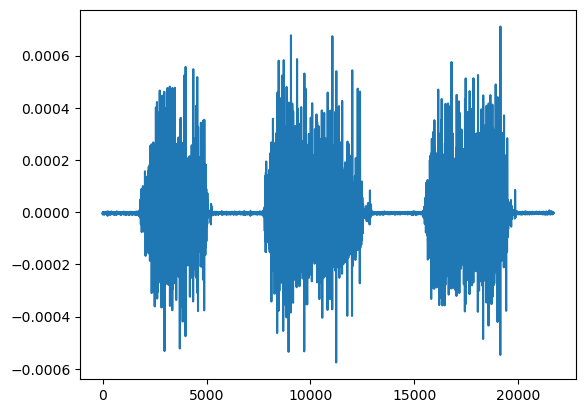

In [4]:
plt.plot(calib.EMG1[0:-1])

In [5]:
filt_1 = []
env_1 = []
for i, ch in enumerate(filt["emg channel"]):
    if ch == 1:
        filt_1.append(filt["filt signal"][i])
for i, ch in enumerate(env["emg channel"]):
    if ch == 1:
        env_1.append(env["enveloped signal"][i]*10)


Text(0.5, 0, 'samples')

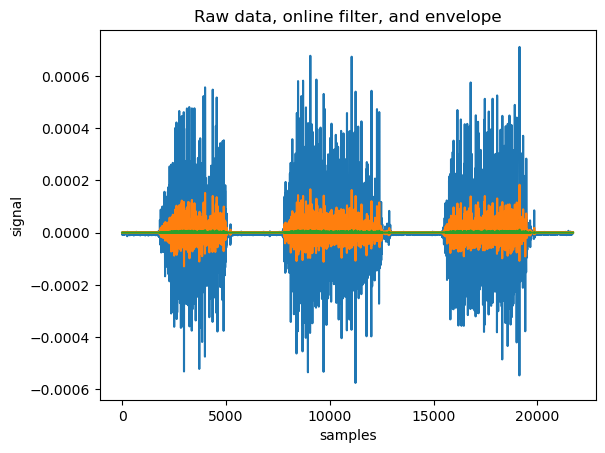

In [7]:
plt.plot(calib.EMG1[0:-1])
plt.plot(np.arange(len(filt_1)-1), np.array(filt_1[0:-1]))

plt.plot(np.arange(len(env_1)-1), np.array(env_1[0:-1]))
plt.title("Raw data, online filter, and envelope")
plt.ylabel("signal")
plt.xlabel("samples")

calibration after stim analysis

In [ ]:
dir = r"C:\Users\User\OneDrive - UW\Quals\MTS-test\2025 - 10 - 15"
_calib = r"\calibration" + r"\MTS_Test_RawFormattedEMGData_2025 - 10 - 15_15 - 16 - 13.csv"
_raw = r"\MTS_Test_RawFormattedEMGData_2025 - 10 - 15_15 - 25 - 59.csv"
_filt = r"\MTS_Test_FiltEMGData_2025 - 10 - 15_15 - 25 - 59.csv"

In [ ]:
calib = pd.read_csv(dir + _calib)
raw = pd.read_csv(dir + _raw)
filt = pd.read_csv(dir + _filt)

In [ ]:
filt_data = bandpass_filter(calib.EMG1)

rectified = (rectify(filt_data))

max_sig = []
for ch in np.arange(16):
    if ch == 0:
        max_sig.append(np.max(rectified))
    else:
        max_sig.append(0)

In [ ]:
env = lowpass_filter(rectified,lowcut=2)

In [ ]:
plt.plot(calib.EMG1)
plt.plot(filt_data)
plt.plot(rectified)
plt.plot(env) # why is the scale off?
# plt.legend()
plt.show()

In [ ]:
r_filt = []
for i, ch in enumerate(filt["emg channel"]):
    if ch == 1:
        r_filt.append(filt["filt signal"][i])

In [ ]:
o_filt = bandpass_filter(raw.EMG1)

In [ ]:
l = 20000
h = 32000
plt.plot(raw.EMG1[l:h])
# plt.show()
plt.plot(np.arange(l,h,1),o_filt[l:h])
plt.show()

In [ ]:
end_ind = 157100
plt.plot(raw.EMG1[0:end_ind])
# filtering doesn't start immediately, repeat with filtering starting immediately
# plt.plot(np.arange(end_ind), r_filt[0:end_ind])
plt.plot(np.arange(end_ind),o_filt[0:end_ind])
plt.show()
plt.plot(np.arange(len(r_filt)),r_filt[0:len(r_filt)])

In [ ]:
_env = r"\MTS_Test_EnvData_2025 - 10 - 15_15 - 25 - 59.csv"
env = pd.read_csv(dir+_env)

In [ ]:
env_data = []
for i, ch in enumerate(env["emg channel"]):
    if ch == 1:
        # not the exact same number of samples as the filtered data
        env_data.append(env["enveloped signal"][i])

In [ ]:
r_filt = np.array(r_filt)

In [ ]:
plt.plot(env_data[0:100])
# bad real-time low-pass filter at the moment
plt.plot(abs(r_filt[0:100]))
plt.show()